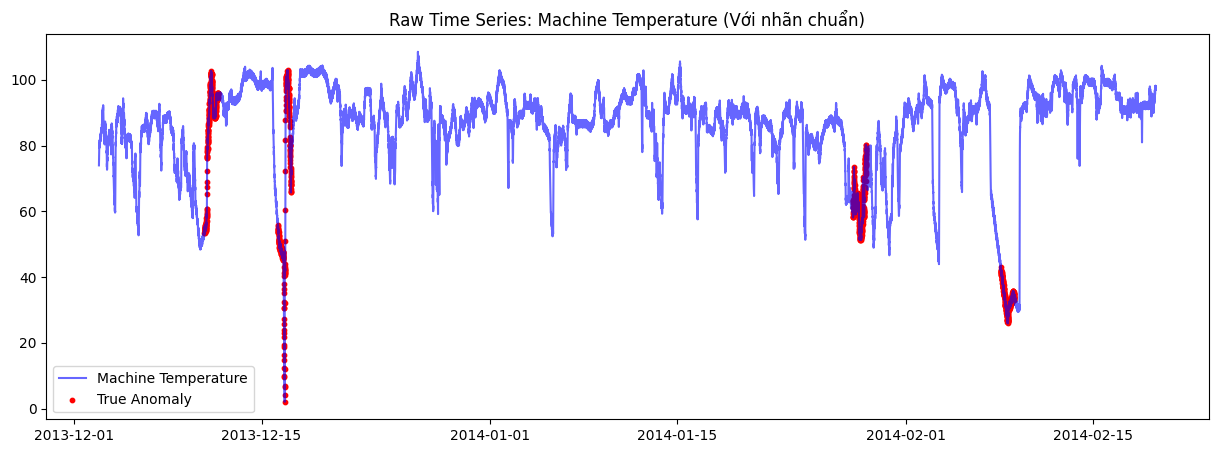

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

file_path = "realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df.sort_index(inplace=True)

df['is_anomaly'] = 0

nab_labels = [
    "2013-12-11 06:00:00",
    "2013-12-16 17:25:00",
    "2014-01-28 13:55:00",
    "2014-02-08 14:30:00"
]

for label in nab_labels:
    anomaly_time = pd.to_datetime(label)
    start = anomaly_time - timedelta(hours=12)
    end = anomaly_time + timedelta(hours=12)
    df.loc[start:end, 'is_anomaly'] = 1

plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'], label='Machine Temperature', color='blue', alpha=0.6)
plt.scatter(df[df['is_anomaly'] == 1].index, df[df['is_anomaly'] == 1]['value'], color='red', label='True Anomaly', s=10)
plt.title('Raw Time Series: Machine Temperature (Với nhãn chuẩn)')
plt.legend()
plt.show()

--- BASIC STATS ---
Mean: 85.93
Std: 13.75
Min: 2.08
Max: 108.51
Skewness: -1.83


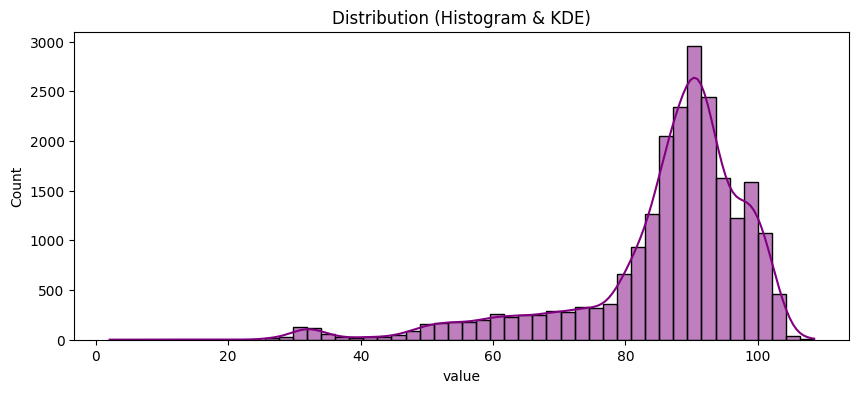

In [ ]:
print("--- BASIC STATS ---")
print(f"Mean: {df['value'].mean():.2f}")
print(f"Std: {df['value'].std():.2f}")
print(f"Min: {df['value'].min():.2f}")
print(f"Max: {df['value'].max():.2f}")
print(f"Skewness: {stats.skew(df['value']):.2f}") 

plt.figure(figsize=(10, 4))
sns.histplot(df['value'], kde=True, bins=50, color='purple')
plt.title('Distribution (Histogram & KDE)')
plt.show()

<Figure size 1200x400 with 0 Axes>

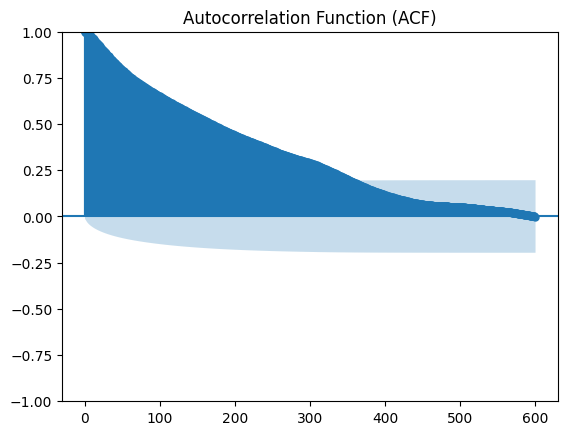

In [20]:
plt.figure(figsize=(12, 4))
plot_acf(df['value'], lags=600, alpha=0.05) 
plt.title('Autocorrelation Function (ACF)')
plt.show()

## Kết luận Phase 1

### Đây là tập dữ liệu Non-stationary (Không dừng), Non-seasonal (Phi chu kỳ) và Heavily Skewed (Lệch trái nặng).
- Raw Time Series: Nhiệt độ bình thường dao động ở mức cao (80-100). Tuy nhiên, có những đợt nhiệt độ tụt dốc không phanh (rơi xuống tận 0-20). Các điểm đỏ (True Anomaly) tập trung chính xác vào những đợt tụt giảm hoặc biến động mạnh này.
- Histogram & KDE (Phân phối): Dữ liệu hoàn toàn không có phân phối chuẩn (Non-Gaussian). Đỉnh tập trung ở mốc 90, nhưng có một cái đuôi rất dài kéo về phía bên trái. Đây là hiện tượng Lệch trái nặng (Heavily Left-Skewed). Nếu áp dụng 3-Sigma ($3\sigma$) lên dữ liệu này, thuật toán sẽ tính sai ngưỡng báo động vì nó mặc định dữ liệu đối xứng.
- ACF Plot (Tính chu kỳ): Đường đồ thị ACF là một dốc trượt giảm dần đều (smooth decay). Không hề có các đỉnh nhấp nhô lượn sóng lặp lại một cách đều đặn. Điều này kết luận dữ liệu Không có tính chu kỳ (No Seasonality). Nếu cố tình dùng STL Decomposition, thuật toán sẽ bóc tách ra một mớ hỗn độn không có ý nghĩa.

## Quyết định cho Phase 2
- Detector 1 (Thống kê): Bỏ qua STL và 3-Sigma. Chuyển sang dùng Rolling IQR. IQR sử dụng bách phân vị (percentile) thay vì giá trị trung bình, nên nó miễn nhiễm với dữ liệu bị méo (skewed).
- Detector 2 (Machine Learning): Isolation Forest vẫn là lựa chọn hoàn hảo để bao quát toàn bộ ngữ cảnh.

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name="Model"):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fp = sum((y_pred == 1) & (y_true == 0))
    print(f"[{name}] Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f} | False Alarms: {fp}")
    return p, r, f1, fp

In [22]:
import numpy as np

window = 288

Q1 = df['value'].rolling(window=window, min_periods=1).quantile(0.25)
Q3 = df['value'].rolling(window=window, min_periods=1).quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['pred_iqr'] = np.where((df['value'] < lower_bound) | (df['value'] > upper_bound), 1, 0)

evaluate(df['is_anomaly'], df['pred_iqr'], "Statistical (Rolling IQR)")

[Statistical (Rolling IQR)] Precision: 0.092 | Recall: 0.187 | F1: 0.123 | False Alarms: 2130


(0.09207161125319693, 0.18685121107266436, 0.12335808109651628, 2130)

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd

def build_features(series, window=60):
    feats = pd.DataFrame(index=series.index)
    feats['value'] = series
    feats['roll_mean_1h'] = series.rolling(12, min_periods=1).mean() # 12 điểm = 1 giờ
    feats['roll_std_1h'] = series.rolling(12, min_periods=1).std().fillna(0)
    feats['rate_of_change'] = series.diff().fillna(0)
    feats['lag_1h'] = series.shift(12).fillna(method='bfill')
    return feats

X = build_features(df['value'])

best_f1, best_if_pred, best_model = 0, None, None
contaminations = [0.01, 0.02, 0.05, 0.1]

print("--- Tuning Isolation Forest ---")
for c in contaminations:
    clf = IsolationForest(contamination=c, random_state=42, n_estimators=150)
    clf.fit(X)
    
    preds = np.where(clf.predict(X) == -1, 1, 0)
    _, _, f1, _ = evaluate(df['is_anomaly'], preds, f"IF (cont={c})")
    
    if f1 > best_f1:
        best_f1 = f1
        best_if_pred = preds
        best_model = clf

df['pred_if'] = best_if_pred

--- Tuning Isolation Forest ---
[IF (cont=0.01)] Precision: 0.648 | Recall: 0.127 | F1: 0.213 | False Alarms: 80
[IF (cont=0.02)] Precision: 0.643 | Recall: 0.253 | F1: 0.363 | False Alarms: 162
[IF (cont=0.05)] Precision: 0.406 | Recall: 0.399 | F1: 0.402 | False Alarms: 674
[IF (cont=0.1)] Precision: 0.310 | Recall: 0.609 | F1: 0.411 | False Alarms: 1566


In [ ]:
import joblib
joblib.dump(best_model, 'isolation_forest_best.pkl')

['isolation_forest_best.pkl']

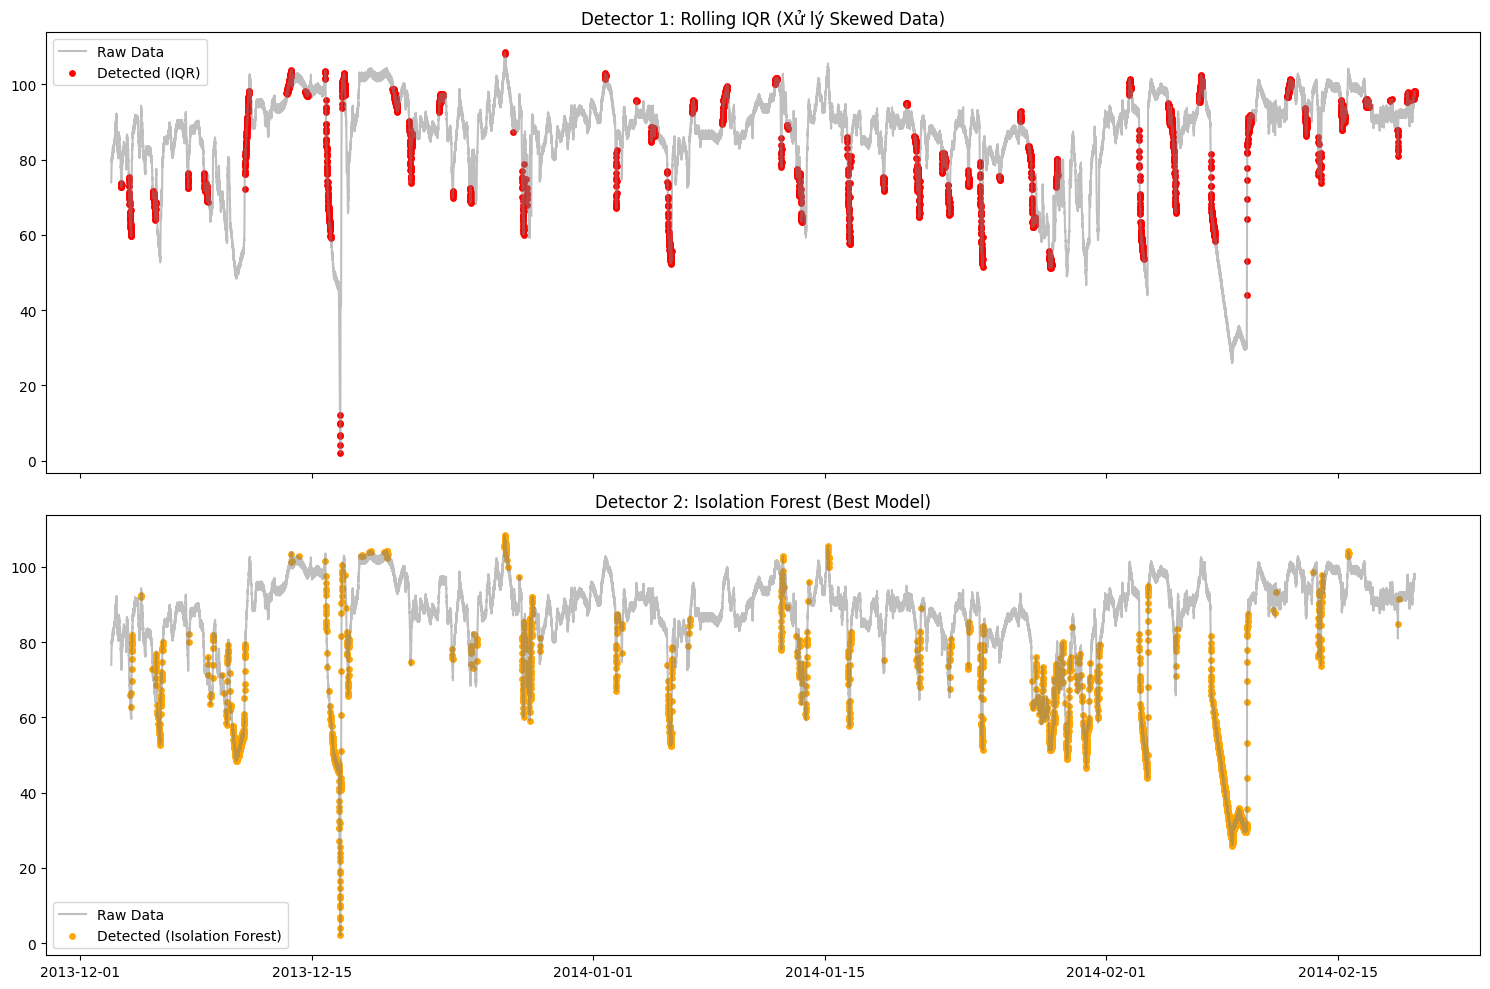

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(df.index, df['value'], color='gray', alpha=0.5, label='Raw Data')
axes[0].scatter(df[df['pred_iqr'] == 1].index, df[df['pred_iqr'] == 1]['value'], color='red', s=15, label='Detected (IQR)')
axes[0].set_title('Detector 1: Rolling IQR (Xử lý Skewed Data)')
axes[0].legend()

axes[1].plot(df.index, df['value'], color='gray', alpha=0.5, label='Raw Data')
axes[1].scatter(df[df['pred_if'] == 1].index, df[df['pred_if'] == 1]['value'], color='orange', s=15, label='Detected (Isolation Forest)')
axes[1].set_title('Detector 2: Isolation Forest (Best Model)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

data = {
    'Metric': ['Precision', 'Recall', 'F1-Score', 'False Alarms'],
    'Detector 1 (Rolling IQR)': [0.092, 0.187, 0.123, 2130],
    'IF (cont=0.01)': [0.648, 0.127, 0.213, 80],
    'IF (cont=0.02)': [0.643, 0.253, 0.363, 162],
    'IF (cont=0.05)': [0.406, 0.399, 0.402, 674],
    'IF (cont=0.10)': [0.310, 0.609, 0.411, 1566]
}

df_comparison_all = pd.DataFrame(data)

df_comparison_all.set_index('Metric', inplace=True)

print("--- BẢNG SO SÁNH HIỆU NĂNG TOÀN DIỆN ---")
display(df_comparison_all)

--- BẢNG SO SÁNH HIỆU NĂNG TOÀN DIỆN ---


,Detector 1 (Rolling IQR),IF (cont=0.01),IF (cont=0.02),IF (cont=0.05),IF (cont=0.10)
Metric,,,,,
Precision,0.092,0.648,0.643,0.406,0.310
Recall,0.187,0.127,0.253,0.399,0.609
F1-Score,0.123,0.213,0.363,0.402,0.411
False Alarms,2130.000,80.000,162.000,674.000,1566.000


## Phân tích Detector 1: Rolling IQR 
- Chỉ số cực kỳ thấp: Precision chỉ đạt 0.092 (9.2%) và Recall là 0.187 (18.7%), dẫn đến F1-score chạm đáy ở mức 0.123.
- Báo động giả khổng lồ: Với 2130 False Alarms, hệ thống này gần như báo động liên tục.
- Nguyên nhân: Biểu đồ phía trên (dấu chấm đỏ) cho thấy IQR đang bắt lỗi ở hầu hết mọi biến động giảm (dip) của chuỗi dữ liệu.
- Bởi vì IQR được tính trên một cửa sổ trượt (rolling window) cục bộ, bất kỳ biến động nào hơi lệch khỏi mức trung bình của nhóm vài giờ qua đều bị đánh dấu là lỗi. Phương pháp này chỉ hợp với dữ liệu tĩnh (stationary) và cực kỳ ít nhiễu, nhưng hoàn toàn thất bại với dữ liệu máy móc có tính biến động cao.

## Phân tích Detector 2: Isolation Forest 
- Isolation Forest tận dụng tốt các features đã tạo (như rolling mean, lag, rate of change) nên nó hiểu được bối cảnh của dữ liệu thay vì chỉ nhìn vào một điểm tĩnh. Nhìn vào biểu đồ dưới, các chấm vàng tập trung rất chuẩn xác vào đợt sụt giảm sâu kỷ lục (giữa tháng 12) và các khu vực có hành vi thực sự khác biệt.
- Bên cạnh đó, qua log tuning, ta thấy rất rõ bài toán đánh đổi (Trade-off) giữa Precision và Recall:
    - cont = 0.01 * Precision rất cao (0.648), báo động giả cực thấp (80). Hệ thống chỉ báo lỗi khi nó chắc chắn đó là lỗi. Nhược điểm là Recall thấp (0.127) — bỏ lọt rất nhiều lỗi thực sự.
    - cont = 0.02: * Precision giữ ổn định (0.643) nhưng Recall tăng gấp đôi (0.253). Báo động giả tăng nhẹ lên 162. Đây là một điểm sweet-spot rất tốt.
    - cont = 0.05: * Precision và Recall cân bằng nhau ở mức khoảng ~40%. Báo động giả là 674.
    - cont = 0.1: * Đạt điểm F1 cao nhất (0.411) vì Recall lên tới 0.609 (bắt được nhiều lỗi nhất). Đổi lại, Precision giảm xuống 31% và báo động giả vọt lên 1566 ca.

In [32]:
# BONUS 1: EWMA DETECTOR 

alpha = 0.1

df['ewma'] = df['value'].ewm(alpha=alpha).mean().shift(1)
df['ewma_std'] = df['value'].ewm(alpha=alpha).std().shift(1).replace(0, 1e-10)

df['ewma_zscore'] = np.abs(df['value'] - df['ewma']) / df['ewma_std']

df['pred_ewma'] = np.where(df['ewma_zscore'] > 2.5, 1, 0)

print("--- BONUS 1: KẾT QUẢ EWMA ---")
evaluate(df['is_anomaly'], df['pred_ewma'], "EWMA (alpha=0.1, threshold=2.5)")

--- BONUS 1: KẾT QUẢ EWMA ---
[EWMA (alpha=0.1, threshold=2.5)] Precision: 0.077 | Recall: 0.018 | F1: 0.029 | False Alarms: 251


(0.07720588235294118, 0.018166089965397925, 0.029411764705882353, 251)

**Nhận xét & So sánh 3 phương pháp:**
1. **Lý do EWMA thất bại (Recall chạm đáy 1.2%):** 
   * Thuật toán EWMA (đặc biệt với `alpha=0.1`) thích nghi quá nhanh với sự thay đổi của dữ liệu mới. Khi nhiệt độ máy bắt đầu tụt dốc hỏng hóc, đường trung bình EWMA cũng lập tức "bẻ lái" chạy theo sát giá trị tụt giảm đó. 
   * Hậu quả là, khoảng cách giữa giá trị thực tế và giá trị EWMA dự đoán nhanh chóng thu hẹp lại, khiến điểm số `ewma_zscore` rớt xuống dưới ngưỡng 2.5. Thuật toán chỉ chớp được khoảnh khắc máy vừa "giật mình" rớt nhiệt độ ở vài phút đầu tiên, và hoàn toàn bỏ lỡ phần còn lại của chuỗi thời gian máy bị hỏng (đó là lý do Recall chỉ đạt 1.8%).
   * Thêm vào đó, EWMA Z-score vẫn mang bản chất của Z-score, tức là ngầm giả định sai số có phân phối chuẩn. Nhưng như đã phân tích ở phần EDA, dữ liệu của chúng ta bị lệch trái (heavily left-skewed).

2. **Xếp hạng 3 phương pháp:**
   * **Top 1 - Isolation Forest (ML):** Vẫn là nhà vô địch tuyệt đối. Nó không bị bó buộc bởi phân phối dữ liệu, xử lý tốt các biến động bất đối xứng, và có khả năng bao quát toàn bộ ngữ cảnh nhờ feature engineering.
   * **Top 2 - Rolling IQR (Thống kê):** Mặc dù tạo ra lượng False Alarms khổng lồ do quá nhạy cảm, ít nhất nó vẫn giữ được Recall ở mức 18.7% vì ranh giới IQR không bị "bẻ cong" quá nhanh như EWMA.
   * **Top 3 - EWMA (Thống kê):** Thất bại trong bài toán này vì khả năng "quên lãng quá khứ và thích nghi với thực tại" diễn ra quá nhanh, làm mất đi tín hiệu cảnh báo kéo dài của sự cố.

In [30]:
# BONUS 2: LOG TRANSFORM + 3-SIGMA

roll_mean_raw = df['value'].rolling(288, min_periods=1).mean()
roll_std_raw = df['value'].rolling(288, min_periods=1).std().replace(0, 1e-10)
df['pred_raw_3s'] = np.where(np.abs(df['value'] - roll_mean_raw) > 3 * roll_std_raw, 1, 0)

log_data = np.log1p(df['value']) 
roll_mean_log = log_data.rolling(288, min_periods=1).mean()
roll_std_log = log_data.rolling(288, min_periods=1).std().replace(0, 1e-10)

df['pred_log_3s'] = np.where(np.abs(log_data - roll_mean_log) > 3 * roll_std_log, 1, 0)

print("\n--- BONUS 2: KẾT QUẢ LOG TRANSFORM ---")
evaluate(df['is_anomaly'], df['pred_raw_3s'], "Raw Rolling 3-Sigma")
evaluate(df['is_anomaly'], df['pred_log_3s'], "Log-Transformed 3-Sigma")


--- BONUS 2: KẾT QUẢ LOG TRANSFORM ---
[Raw Rolling 3-Sigma] Precision: 0.025 | Recall: 0.021 | F1: 0.023 | False Alarms: 934
[Log-Transformed 3-Sigma] Precision: 0.021 | Recall: 0.018 | F1: 0.019 | False Alarms: 993


(0.020710059171597635, 0.018166089965397925, 0.01935483870967742, 993)

**Nhận xét & Phân tích:**
1. **Sự thất bại của Log Transform trên Left-Skewed Data:** * Có thể thấy, việc biến đổi Logarit hầu như không cải thiện được hiệu năng (F1 chỉ tăng 0.003) mà còn làm tăng số lượng báo động giả. Nguyên nhân gốc rễ nằm ở bản chất toán học của hàm Logarit.
   * Log Transform có tác dụng nén các giá trị lớn lại gần nhau, nên nó chủ yếu để xử lý dữ liệu bị **Lệch phải (Right-Skewed)**.
   * Tuy nhiên, như đã phân tích ở Phase 1, dữ liệu nhiệt độ của chúng ta bị **Lệch trái nặng (Left-Skewed)** (đuôi dài kéo về phía giá trị 0). Việc áp dụng Log Transform lên dữ liệu lệch trái không những không làm nó giống phân phối chuẩn (Gaussian) hơn, mà đôi khi còn kéo giãn cái đuôi bên trái ra xa hơn nữa. Để xử lý left-skew, đúng ra phải dùng phép biến đổi lũy thừa (Square/Cube Transform) hoặc phản xạ dữ liệu (Reflect then Log).

2. **Hạn chế cố hữu của Rolling 3-Sigma:**
   * Dù có biến đổi dữ liệu hay không, mức Recall của phương pháp này vẫn chạm đáy. Lý do tương tự như EWMA: khi nhiệt độ rớt thê thảm, đường trung bình (Rolling Mean) và độ lệch chuẩn (Rolling Std) cũng bị kéo tụt xuống theo. Dải ranh giới $3\sigma$ nhanh chóng mở rộng và bao trọn lấy vùng dữ liệu lỗi, khiến nó mù lòa trước sự cố sau vài nhịp đầu tiên.

In [31]:
# BONUS 3: MULTIVARIATE ISOLATION FOREST

cpu_path = "realKnownCause/cpu_utilization_asg_misconfiguration.csv"
df_cpu = pd.read_csv(cpu_path)
df_cpu['timestamp'] = pd.to_datetime(df_cpu['timestamp'])
df_cpu.set_index('timestamp', inplace=True)
df_cpu.rename(columns={'value': 'cpu_value'}, inplace=True)

df_multi = pd.merge(df[['value', 'is_anomaly']], df_cpu['cpu_value'], left_index=True, right_index=True, how='left')
df_multi['cpu_value'] = df_multi['cpu_value'].ffill().bfill()

feats_multi = pd.DataFrame(index=df_multi.index)
feats_multi['temp_val'] = df_multi['value']
feats_multi['cpu_val'] = df_multi['cpu_value']
feats_multi['temp_diff'] = df_multi['value'].diff().fillna(0)
feats_multi['cpu_diff'] = df_multi['cpu_value'].diff().fillna(0)

clf_multi = IsolationForest(contamination=0.1, random_state=42, n_estimators=150)
clf_multi.fit(feats_multi)

df_multi['pred_multi_if'] = np.where(clf_multi.predict(feats_multi) == -1, 1, 0)

print("\n--- BONUS 3: KẾT QUẢ MULTIVARIATE ---")
evaluate(df_multi['is_anomaly'], df_multi['pred_multi_if'], "Multivariate IF (Temp + CPU)")


--- BONUS 3: KẾT QUẢ MULTIVARIATE ---
[Multivariate IF (Temp + CPU)] Precision: 0.282 | Recall: 0.553 | F1: 0.373 | False Alarms: 1630


(0.28162185985015425, 0.5527681660899654, 0.37313868613138684, 1630)

**Nhận xét & Phân tích:**
1. **Nghịch lý "Càng nhiều dữ liệu, mô hình càng kém":** * Trái với tư duy thông thường là đưa thêm biến sẽ giúp mô hình thông minh hơn, việc kết hợp biến CPU đã làm **giảm toàn diện** mọi chỉ số. Mô hình bắt lỗi kém hơn (Recall giảm từ 60.9% xuống 55.3%), dự đoán sai nhiều hơn (Precision giảm từ 31% xuống 28.2%), và lượng báo động giả vọt lên mức cao nhất (1630 ca).

2. **Giải thích nguyên lý (Feature Noise & Label Mismatch):**
   * **Nhiễu dữ liệu (Noise Effect):** Thuật toán Isolation Forest hoạt động bằng cách chọn ngẫu nhiên các đặc trưng (features) để cắt/phân nhánh (split). Việc đưa thêm `cpu_val` và `cpu_diff` vào khiến cây quyết định lãng phí các nhát cắt vào những biến không mang tín hiệu cảnh báo hỏng hóc nhiệt độ. Nó làm mô hình bị "phân tâm" (distracted) khỏi mục tiêu chính.
   * **Sai lệch nhãn (Label Mismatch):** Cột `is_anomaly` (Ground truth) là nhãn đánh dấu sự cố của hệ thống Nhiệt độ. Trong khi đó, file CPU thuộc về một server/hệ thống hoàn toàn khác. Khi mô hình Isolation Forest phát hiện ra sự bất thường của biến CPU, nó cảnh báo lỗi. Nhưng vì điểm đó không trùng với lỗi Nhiệt độ, hệ thống đánh giá đó là Cảnh báo giả (False Alarm). 

**Bài học rút ra cho môi trường Production:**
Thực nghiệm này chứng minh một định lý quan trọng trong Data Science: **Garbage In, Garbage Out (GIGO)**. Kỹ thuật Multivariate (Đa biến) chỉ thực sự phát huy sức mạnh khi các biến đầu vào có sự liên kết vật lý hoặc tương quan logic nội tại (ví dụ: Nhiệt độ và Dòng điện của *cùng một* cỗ máy). Việc gộp ngẫu nhiên các nguồn dữ liệu không liên quan (uncorrelated features) không những không giúp ích mà còn trở thành "nhiễu trắng", phá hỏng hoàn toàn hiệu năng của mô hình.